

SECTION 1: Title + Imports



In [4]:
print("===== LOGISTIC REGRESSION MODEL STARTED =====")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

===== LOGISTIC REGRESSION MODEL STARTED =====


SECTION 2: Dataset Load

In [5]:
from google.colab import files
uploaded = files.upload()

data = pd.read_csv("train.csv")

print("Dataset Loaded Successfully")
print(data.head())

Saving train.csv to train (3).csv
Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123     

SECTION 3: Basic Info

In [6]:
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)

print("\nMissing Values:\n")
print(data.isnull().sum())

Shape: (891, 12)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


SECTION 4: Data Cleaning

In [7]:
df = data.copy()

# Drop unwanted columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values handled")

Missing values handled


SECTION 5: Feature & Target

In [8]:
y = df['Survived']
X = df.drop('Survived', axis=1)

# Convert categorical
X = pd.get_dummies(X, drop_first=True)

print("Features ready:", X.shape)

Features ready: (891, 8)


SECTION 6: Feature Scaling

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling Done")

Scaling Done


SECTION 7: Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Train Size: (712, 8)
Test Size: (179, 8)
Training Accuracy: 0.8019662921348315
Testing Accuracy: 0.8100558659217877


SECTION 8: Model Training

In [11]:
model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


SECTION 9: Prediction

In [12]:
y_pred = model.predict(X_test)

print("Prediction Done")

Prediction Done


SECTION 10: Accuracy & Report

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



SECTION 11: Confusion Matrix

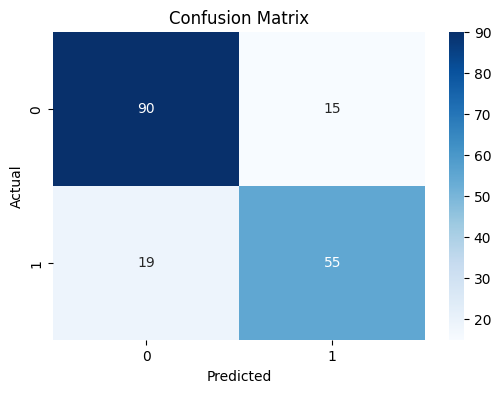

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SECTION 12: Feature Importance

In [15]:
coef = pd.DataFrame(model.coef_, columns=X.columns)

print("Feature Importance:\n")
print(coef)

Feature Importance:

     Pclass       Age     SibSp     Parch      Fare  Sex_male  Embarked_Q  \
0 -0.798639 -0.405969 -0.330576 -0.100289  0.119836  -1.28355   -0.040276   

   Embarked_S  
0   -0.195392  


SECTION 13: Sample Prediction

In [16]:
sample = X_test[0].reshape(1, -1)

print("Sample Prediction:", model.predict(sample))

Sample Prediction: [0]


SECTION 14: Final Output

In [17]:
print("\n===== LOGISTIC REGRESSION COMPLETED =====")


===== LOGISTIC REGRESSION COMPLETED =====
